In [1]:
import os
import torch
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.utils.data import DataLoader,random_split

from Tools.model_tools import load_configs, add_config
from Tools.data_utils import SimulationData,generate_input_filename
from Encoder import*

### Input dataset:

Insert the Embedding and Noise parameters of the desired data to train the VAE

In [2]:
tau = 3
embedding_dim = 30
r = 20
alpha = 0
beta = 0
simulation_name= generate_input_filename(tau, embedding_dim, r, alpha, beta)
model_name = "30-20"      
print(simulation_name)

delay3dim30,20_noise0,0


In [3]:
# Percorso del database
model_database_path = "encoderDatabase.json"

# Carica tutte le configurazioni disponibili
all_configs = load_configs(model_database_path)

print(model_name)

30-20


#### VAE configuration:

Choose the configuration of the Network.
Here you can change the geometry, hyperparameters and training parameters of the VAE.
The model name is used to distinguish between network with same parameters but different training option.

In [4]:
# Se vuoi creare una nuova configurazione

layer_dims = [r, 15, 10, 5]  # Match legendre basis with shape of input
latent_dim = layer_dims[-1]

new_config = {
    "layer_dims" :layer_dims,
    "latent_dim": latent_dim,
    "beta_method": "sigmoid", #constant, sigmoid, linear, linear_decay, exponential_decay
    "beta_value": 0.01, # Valore di beta
    "kl_annealing_epochs":  250, # Epoche di warmup
    "decay_start": 100, # Epoch di inizio del decadimento
    "decay_epoch": 50, # Durata del decadimento
    "early_stopping": {"patience": 10, "delta": -1}, # Early stopping -1 per disattivare
    "dataset": simulation_name,
    "batch_size": 32,
    "optimizer": "Adam",
    "learning_rate": 0.02,
    "scheduler": {
        "type": "ReduceLROnPlateau", 
        "params": {

            # Parametri per ReduceLROnPlateau
            "mode": "min",      # Monitora la perdita minima
            "factor": 0.5,      # Fattore di riduzione (LR = LR * factor)
            "patience": 10,     # Numero di epoche senza miglioramenti prima di ridurre LR
            "min_lr": 0.000000001 ,  # Limite inferiore per il LR

            # Parametri per CyclicLR
            "base_lr": 0.0001,  # Minimo LR per CyclicLR
            "max_lr": 0.01,     # Massimo LR per CyclicLR
            "step_size_up": 200,  # Numero di step per aumentare il LR (solo per CyclicLR)

            # Parametri per CosineAnnealingLR
            "T_max": 100,       # Numero di step fino al minimo (solo per CosineAnnealingLR)
                                # Eta min scritto sotto è il valore minimo di LR

            # Parametri per CosineAnnealingWarmRestarts
            "T_0": 10,          # Numero di step per il primo ciclo (solo per CosineAnnealingWarmRestarts)
            "T_mult": 2,        # Fattore moltiplicativo per il ciclo successivo (solo per CosineAnnealingWarmRestarts)
            "eta_min": 0.00000001,  # Valore minimo per CosineAnnealingLR e CosineAnnealingWarmRestarts
        }
    }
}

epochs = 400

# Aggiungi la nuova configurazione al database
#add_config(new_config, model_name, model_database_path)
print(all_configs)

{'Model_1': {'layer_dims': [20, 15, 10, 5], 'latent_dim': 5, 'beta_method': 'sigmoid', 'beta_value': 0.01, 'kl_annealing_epochs': 250, 'decay_start': 100, 'decay_epoch': 50, 'early_stopping': {'patience': 10, 'delta': -1}, 'dataset': 'delay3dim100,20_noise0,0', 'batch_size': 32, 'optimizer': 'Adam', 'learning_rate': 0.02, 'scheduler': {'type': 'ReduceLROnPlateau', 'params': {'mode': 'min', 'factor': 0.5, 'patience': 10, 'min_lr': 1e-09, 'base_lr': 0.0001, 'max_lr': 0.01, 'step_size_up': 200, 'T_max': 100, 'T_0': 10, 'T_mult': 2, 'eta_min': 1e-08}}}, 'NoLeg': {'layer_dims': [20, 15, 10, 5], 'latent_dim': 5, 'beta_method': 'sigmoid', 'beta_value': 0.01, 'kl_annealing_epochs': 250, 'decay_start': 100, 'decay_epoch': 50, 'early_stopping': {'patience': 10, 'delta': -1}, 'dataset': 'delay3dim20,20_noise0,0', 'batch_size': 32, 'optimizer': 'Adam', 'learning_rate': 0.02, 'scheduler': {'type': 'ReduceLROnPlateau', 'params': {'mode': 'min', 'factor': 0.5, 'patience': 10, 'min_lr': 1e-09, 'base_l

In [5]:
# Carica una configurazione esistente
selected_model = new_config

# Carica i dati di simulazione
simulation = SimulationData.load_from_params(
    tau=tau, embedding_dim=embedding_dim, r=r, alpha=alpha, beta=beta, input_path="Simulation data"
)

# Seleziona le matrici di Hankel da SimulationData
y1_reduced_data = simulation.projected_H1



# Verifica che gli embedding siano stati generati correttamente
if y1_reduced_data is None:
    raise ValueError("Uno o più embedding non sono stati generati correttamente!")

In [6]:
# Crea il dataset
embedded_dataset = EmbeddedDataset(y1_reduced_data)
print("embedded_dataset shape:", embedded_dataset.data.shape)
print("embedded_dataset n. samples:", len(embedded_dataset.data))

# Suddivisione del dataset
total_size = len(embedded_dataset)
train_size = int(0.60 * total_size)  # 60% per il training
val_size = total_size - train_size   # 40% per la validazione

# Suddivisione del dataset senza random split
train_data = torch.utils.data.Subset(embedded_dataset, range(train_size))
val_data = torch.utils.data.Subset(embedded_dataset, range(train_size, total_size))

# Stampa delle dimensioni
print(f"SHAPE dei campioni di Training: {train_data.dataset.data.shape}")
print(f"SHAPE dei campioni di Validazione: {val_data.dataset.data.shape}")

# Prepara il DataLoader
batch_size = selected_model["batch_size"]
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

# Debug del batch
for batch in train_loader:
    x, y = batch  # Decomponi input e output
    x = x.float()
    y = y.float()
    print("Shape of input:", x.shape)
    break



embedded_dataset shape: torch.Size([9913, 20])
embedded_dataset n. samples: 9913
SHAPE dei campioni di Training: torch.Size([9913, 20])
SHAPE dei campioni di Validazione: torch.Size([9913, 20])
Shape of input: torch.Size([32, 20])


### Training the VAE:

We will train the VAE to reconstruct the input. 
The focus of this section is enabling the Encoder to learn a solid and meaningfull latent rapresentation of the sistem

Epoch [1/400], Rec Loss: 0.5210, KLD Loss: 12.9113, Beta: 0.0000, KLD*B = 0.0000 Training Loss: 0.5210, lr = 0.020000
Epoch [2/400], Rec Loss: 0.1628, KLD Loss: 15.9587, Beta: 0.0000, KLD*B = 0.0000 Training Loss: 0.1628, lr = 0.020000
Epoch [3/400], Rec Loss: 0.0703, KLD Loss: 20.7097, Beta: 0.0000, KLD*B = 0.0000 Training Loss: 0.0703, lr = 0.020000
Epoch [4/400], Rec Loss: 0.0603, KLD Loss: 23.0963, Beta: 0.0000, KLD*B = 0.0000 Training Loss: 0.0603, lr = 0.020000
Epoch [5/400], Rec Loss: 0.0558, KLD Loss: 24.5337, Beta: 0.0000, KLD*B = 0.0000 Training Loss: 0.0558, lr = 0.020000
Epoch [6/400], Rec Loss: 0.0478, KLD Loss: 25.5178, Beta: 0.0000, KLD*B = 0.0000 Training Loss: 0.0478, lr = 0.020000
Epoch [7/400], Rec Loss: 0.0418, KLD Loss: 26.4106, Beta: 0.0000, KLD*B = 0.0000 Training Loss: 0.0418, lr = 0.020000
Epoch [8/400], Rec Loss: 0.0372, KLD Loss: 27.1404, Beta: 0.0000, KLD*B = 0.0000 Training Loss: 0.0372, lr = 0.020000
Epoch [9/400], Rec Loss: 0.0297, KLD Loss: 27.5566, Beta

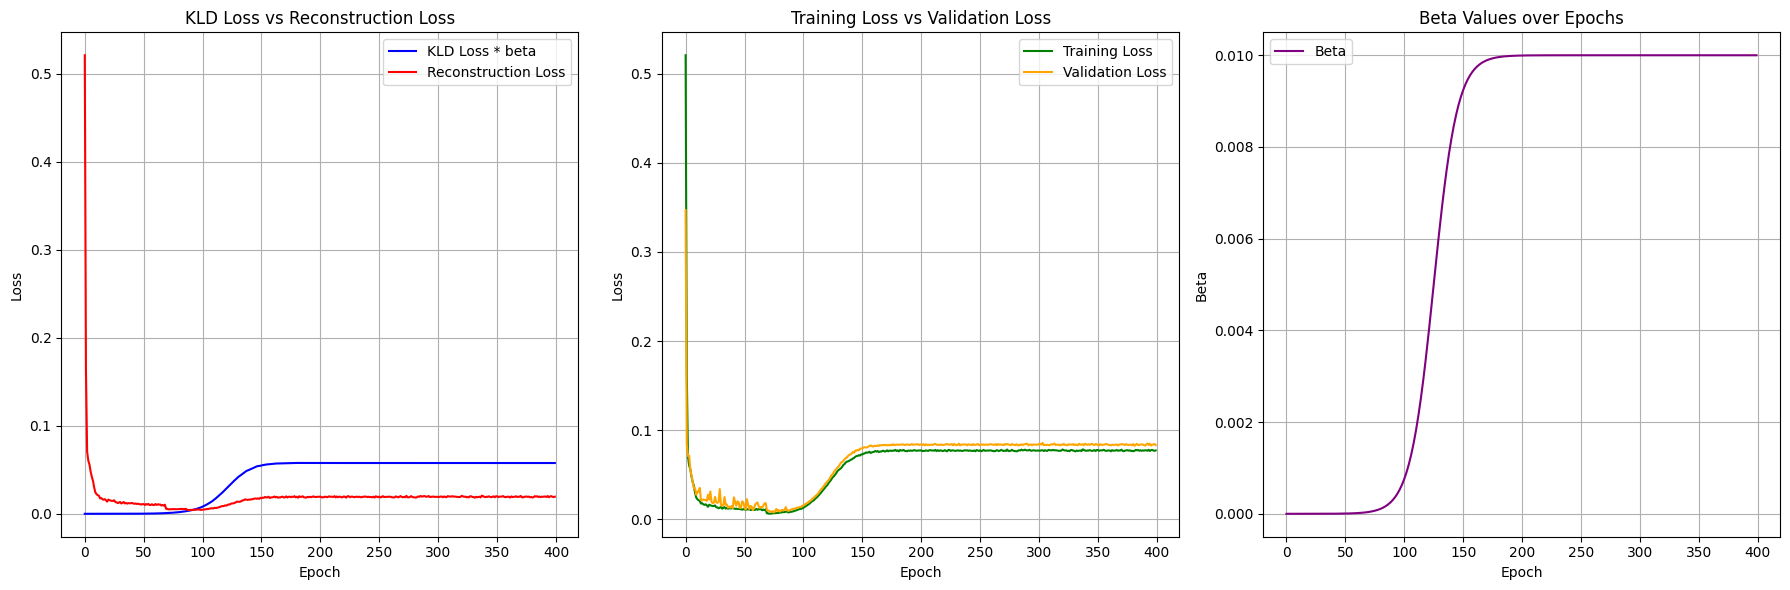

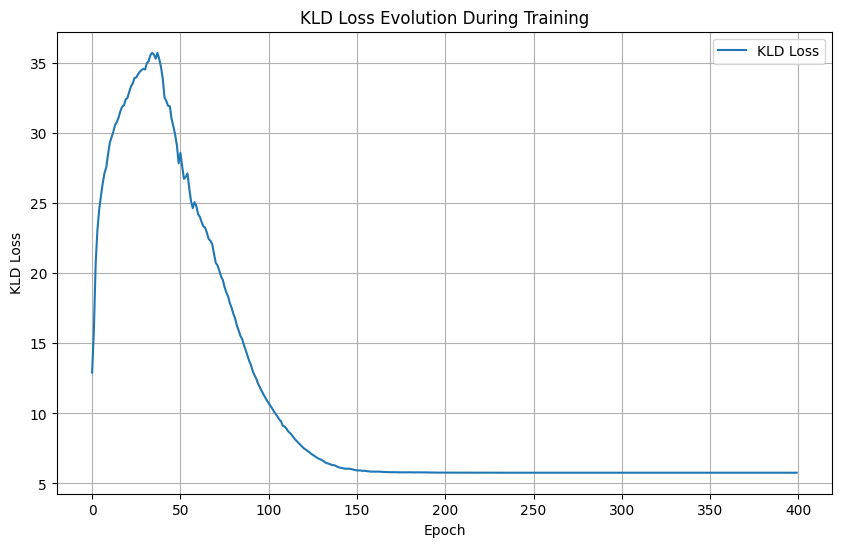

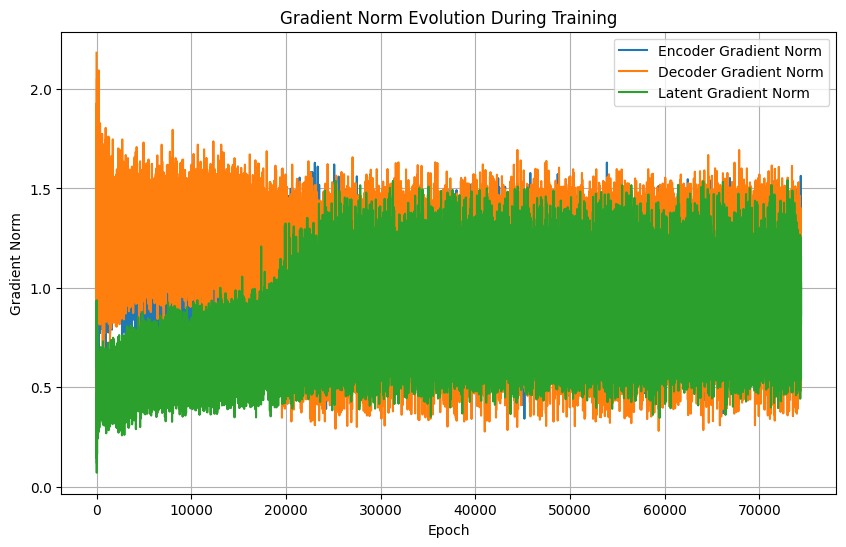

In [7]:
# Creazione del Modello

encoder = Encoder(layer_dims)
decoder = Decoder(layer_dims)

vae_model = VAE(encoder, decoder)

#for name, param in vae_model.named_parameters():
#    print(name, param.shape)

# Configura ottimizzatore e scheduler dai parametri del modello
optimizer = optim.Adam(vae_model.parameters(), lr=selected_model["learning_rate"])
scheduler_config = selected_model.get("scheduler")
scheduler = get_scheduler(optimizer, scheduler_config)

# Esecuzione del training
train_losses, val_losses, recon_losses, kld_losses,effective_kld_losses, beta_values, stopped_epoch, gradient_history, lr_evolution = trainEncoder(
    epochs=epochs,
    train_loader=train_loader,
    val_loader=val_loader,  # Aggiungi se hai un dataset di validazione
    model=vae_model,
    optimizer=optimizer,
    scheduler=scheduler,
    scheduler_config=scheduler_config,
    kl_annealing_epochs=selected_model["kl_annealing_epochs"],
    decay_epoch=selected_model["decay_epoch"],
    decay_start=selected_model["decay_start"],
    beta_method=selected_model["beta_method"],
    beta_value=selected_model["beta_value"],
    early_stopping_params=selected_model["early_stopping"]
)




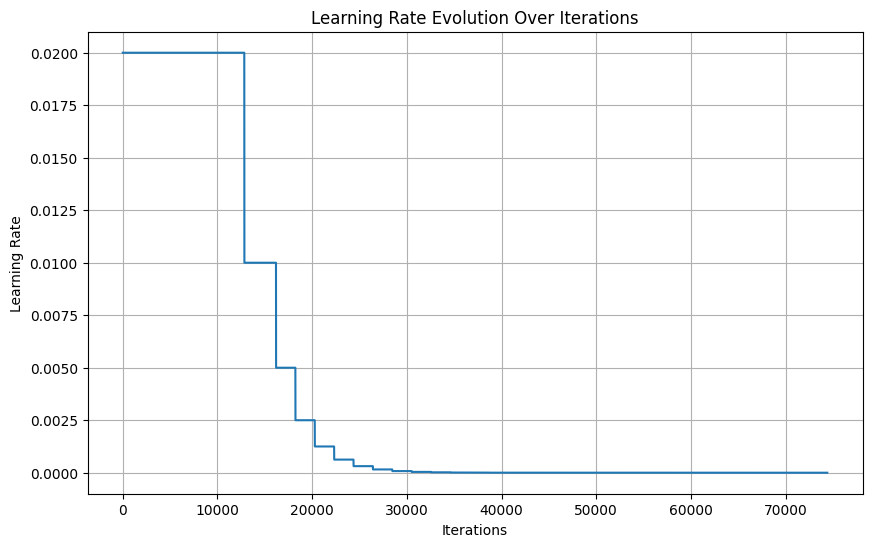

In [8]:
# Plot the learning rate evolution
plt.figure(figsize=(10, 6))
plt.plot(lr_evolution, label='Learning Rate Evolution')
plt.xlabel('Iterations')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Evolution Over Iterations')
plt.grid(True)
plt.show()

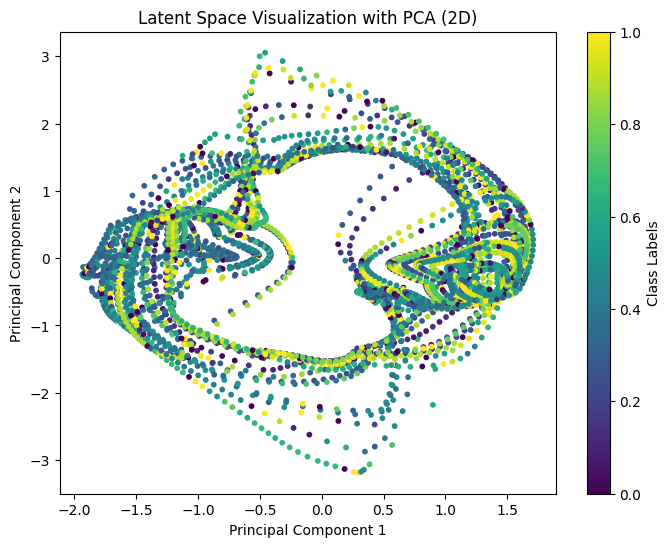

In [9]:
# Esegui la visualizzazione
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
visualize_latent_space_with_pca(vae_model, val_data, device=device, n_components=2)

In [10]:
# Carica la configurazione creata nel Databse degli Encoder
all_configs = load_configs(model_database_path)

This code will save the training and the useful data for the analysis.
It will also load the Model configuration into the Encoder Database.

In [11]:
# Salva la configurazione nel database
add_config(new_config, model_name, model_database_path)
# Salva il modello
model_name += ".pth"

denormalizing_params = {
    "min_h1": simulation.min_h1,
    "max_h1": simulation.max_h1,
    "min_h2_1": simulation.min_h2_1,
    "max_h2_1": simulation.max_h2_1,
    "min_h2_2": simulation.min_h2_2,
    "max_h2_2": simulation.max_h2_2
}

save_encoder(
    encoder=encoder,
    decoder=decoder,
    optimizer=optimizer,
    train_data=train_data,
    val_data=val_data,  # Aggiungi se hai un dataset di validazione
    epoch=50,
    stopped_epoch=stopped_epoch,
    encoder_layers=layer_dims,
    decoder_layers=layer_dims,
    train_losses=train_losses,
    val_losses=val_losses,
    recon_losses=recon_losses,
    kld_losses=kld_losses,
    effective_kld_losses=effective_kld_losses,
    beta_values=beta_values,
    gradient_history=gradient_history,
    denormalizing_params= denormalizing_params,
    legendreBasis= simulation.P,
    H1= simulation.H1,
    H2_1= simulation.H2_1,
    H2_2= simulation.H2_2,
    output_folder="Encoder Models",
    model_name=model_name
)

Model saved to Encoder Models/30-20.pth
